# QA — Reconciliation Metabase vs Adjust (CDS Android)

Notebook orchestration: gọi `clients/` để lấy data, gọi `reconciliation/` để xử lý.
Toàn bộ logic thật nằm trong 2 package đó — sửa logic ở đó, không sửa ở đây.

Đối chiếu đủ 12 chỉ số: ROAS D0-D28, Revenue D0-D28, Cost, Installs — sai số tương đối
thống nhất `ratio = mb/adj`, ngưỡng `config.THRESHOLD_PCT`. Cohort chưa đủ maturity theo
`Cohort Age` bị loại khỏi so sánh tự động.

In [74]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import config
import run_config as rc
from clients.adjust_client import AdjustClient
from clients.metabase_client import MetabaseClient
from reconciliation.normalize import normalize_metabase, normalize_adjust, filter_excluded_dates
from reconciliation.merge import merge_sources, report_join_gaps
from reconciliation.flags import build_detail
from reconciliation.summary import summarize, top_discrepancy
from reconciliation import eda

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 0. (Tuỳ chọn) Override config riêng cho lần chạy này

`config.EXCLUDED_DATES` và `config.DATA_ASOF_DATE` là kiến thức riêng theo từng lần chạy
(ngày nào bị lỗi, chốt dữ liệu vào lúc nào) — override trực tiếp ở đây thay vì sửa `config.py`
nếu chỉ dùng cho 1 lần đối chiếu cụ thể.

In [75]:
# Toàn bộ lựa chọn cho lần chạy này đến từ run_config.py — sửa ở đó, không sửa ở đây.
game = config.GAMES[rc.GAME_KEY]
adjust_app_token = config.get_adjust_app_token(rc.GAME_KEY)

config.EXCLUDED_DATES = rc.EXCLUDED_DATES
config.DATA_ASOF_DATE = rc.DATA_ASOF_DATE

# 1 nguồn duy nhất cho khoảng ngày -> tự format đúng cho cả 2 API,
# không còn rủi ro sửa 1 chỗ quên chỗ kia.
metabase_date_range = f"{rc.DATE_PERIOD_START}~{rc.DATE_PERIOD_END}"
adjust_date_period = f"{rc.DATE_PERIOD_START}:{rc.DATE_PERIOD_END}"

print(f"Đang chạy cho: {game['label']}")
print(f"Khoảng ngày: {rc.DATE_PERIOD_START} -> {rc.DATE_PERIOD_END}")
print(f"EXCLUDED_DATES: {rc.EXCLUDED_DATES or '(không có)'}")
print(f"DATA_ASOF_DATE: {rc.DATA_ASOF_DATE or '(dùng ngày hệ thống hiện tại)'}")

Đang chạy cho: Game B (CDS) — iOS
Khoảng ngày: 2026-07-30 -> 2026-09-12
EXCLUDED_DATES: (không có)
DATA_ASOF_DATE: 2026-09-12


## 1. Lấy dữ liệu Metabase

In [76]:
mb = MetabaseClient(base_url=config.METABASE_URL, api_key=config.METABASE_API_KEY)

parameters = mb.build_parameters(
    game["metabase_card_id"],
    cohort_date=metabase_date_range,
    game=game["metabase_game"],
    platform=game["metabase_platform"],
    active_only=[True],
)

df_mb = mb.query_card(game["metabase_card_id"], parameters)
print("Số dòng Metabase:", df_mb.shape[0])
df_mb.head()

Số dòng Metabase: 90


,Cohort Date,Game,Platform,Network,Campaign,Cost,Adjust Installs,CPI,ROAS D0,ROAS D3,ROAS D7,ROAS D14,ROAS D28,Revenue D0,Revenue D3,Revenue D7,Revenue D14,Revenue D28,Revenue Complete Through
0,2026-09-12T00:00:00Z,Game B,IOS,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,301.259815,35,8.607423,0.058410,NaN,NaN,NaN,NaN,17.596491,NaN,NaN,NaN,NaN,2026-09-12T00:00:00Z
1,2026-09-12T00:00:00Z,Game B,IOS,APPLOVIN,CDS iOS - D28 AdROAS - 260212,212.124680,48,4.419264,0.079733,NaN,NaN,NaN,NaN,16.913321,NaN,NaN,NaN,NaN,2026-09-12T00:00:00Z
2,2026-09-11T00:00:00Z,Game B,IOS,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,401.377450,33,12.162953,0.140033,NaN,NaN,NaN,NaN,56.206228,NaN,NaN,NaN,NaN,2026-09-12T00:00:00Z
3,2026-09-11T00:00:00Z,Game B,IOS,APPLOVIN,CDS iOS - D28 AdROAS - 260212,276.323363,50,5.526467,0.131285,NaN,NaN,NaN,NaN,36.277025,NaN,NaN,NaN,NaN,2026-09-12T00:00:00Z
4,2026-09-10T00:00:00Z,Game B,IOS,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,163.872464,33,4.965832,0.018377,NaN,NaN,NaN,NaN,3.011454,NaN,NaN,NaN,NaN,2026-09-12T00:00:00Z


## 2. Lấy dữ liệu Adjust
Dùng `config.ADJUST_METRICS_CDS_ANDROID` — đã gồm đủ Installs, Cost, ROAS D0-D28, Revenue D0-D28.

In [77]:
adjust = AdjustClient(api_token=config.ADJUST_API_TOKEN)

df_adjust, adjust_totals = adjust.fetch_report(
    app_token=adjust_app_token,
    dimensions=["day", "network", "campaign_network"],
    metrics=config.get_adjust_metrics(rc.GAME_KEY),   # <-- đổi ở đây
    date_period=adjust_date_period,
    extra_params=game["adjust_extra_params"],
)
print("Số dòng Adjust:", df_adjust.shape[0])
print("Totals:", adjust_totals)
df_adjust.head()

Số dòng Adjust: 90
Totals: {'installs': 19901.0, 'network_cost': 143161.3319, 'roas_ad_cal_d0': 0.0623, 'roas_ad_cal_d3': 0.1972, 'roas_ad_cal_d7': 0.2895, 'roas_ad_cal_d14': 0.3855, 'roas_ad_cal_d28': 0.5018, 'ad_revenue_total_cal_d0': 8922.1167, 'ad_revenue_total_cal_d3': 28136.1472, 'ad_revenue_total_cal_d7': 40560.7137, 'ad_revenue_total_cal_d14': 52188.1921, 'ad_revenue_total_cal_d28': 51503.1157}


,day,network,campaign_network,installs,network_cost,roas_ad_cal_d0,roas_ad_cal_d3,roas_ad_cal_d7,roas_ad_cal_d14,roas_ad_cal_d28,ad_revenue_total_cal_d0,ad_revenue_total_cal_d3,ad_revenue_total_cal_d7,ad_revenue_total_cal_d14,ad_revenue_total_cal_d28
0,2026-07-30,ALV,CDS iOS - D28 BLDROAS - 260625,605,7398.2993,0.0502,0.1938,0.2906,0.3872,0.5554,371.2839,1433.9461,2150.1631,2864.4606,4108.6881
1,2026-08-02,ALV,CDS iOS - D28 AdROAS - 260212,562,3311.703,0.0608,0.1899,0.3094,0.4343,0.5083,201.3204,628.7431,1024.553,1438.3703,1683.2587
2,2026-07-30,ALV,CDS iOS - D28 AdROAS - 260212,494,2470.4358,0.0793,0.2153,0.292,0.3583,0.4473,195.8186,531.863,721.2633,885.0997,1105.0949
3,2026-08-01,ALV,CDS iOS - D28 BLDROAS - 260625,478,6331.4672,0.0606,0.1837,0.2622,0.3515,0.465,383.6218,1162.8852,1660.1729,2225.8028,2944.3179
4,2026-08-09,ALV,CDS iOS - D28 BLDROAS - 260625,475,3876.9935,0.0658,0.2074,0.3289,0.4468,0.577,255.2493,804.2519,1274.9554,1732.124,2237.0122


## 3. Normalize + loại ngày lỗi + Merge

In [78]:
mb_norm = normalize_metabase(df_mb)
adj_norm = normalize_adjust(df_adjust)

mb_norm = filter_excluded_dates(mb_norm, config.EXCLUDED_DATES)
adj_norm = filter_excluded_dates(adj_norm, config.EXCLUDED_DATES)

merged = merge_sources(mb_norm, adj_norm)
join_stats = report_join_gaps(merged)


Khớp cả 2 nguồn: 90 dòng
Chỉ có ở Metabase: 0 dòng
Chỉ có ở Adjust: 0 dòng


## 4. Tính bảng đối chiếu chi tiết (long-format)
Mỗi dòng = 1 cohort x 1 metric. Dùng `merged` đầy đủ (kể cả phần lệch join key) —
các dòng đó tự ra flag "N/A (thiếu dữ liệu)", không bị âm thầm bỏ qua.

In [79]:
metric_map = config.get_metric_map(rc.GAME_KEY)
detail = build_detail(merged, metric_map)
detail.head(10)

Cohort Age tính theo DATA_ASOF_DATE = 2026-09-12
EXCLUDE_IMMATURE_COHORTS = True
[CHỐT] Sai số tương đối ratio = mb/adj. Ngưỡng Discrepancy: |rel_diff_pct| > 5.0%

Bảng detail: 1080 dòng (= 90 cohort x 12 chỉ số)
Số dòng bị loại vì cohort chưa đủ maturity: 208


,cohort_date,network,campaign,metric,cohort_age_days,is_immature,mb_value,adjust_value,abs_diff,ratio,rel_diff_pct,flag
0,2026-07-30,APPLOVIN,CDS iOS - D28 AdROAS - 260212,COST,44,False,2470.435774,2470.4358,-0.000026,1.000000,-0.0000,OK
1,2026-07-30,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,COST,44,False,7398.299332,7398.2993,0.000032,1.000000,0.0000,OK
2,2026-07-30,APPLOVIN,CDS iOS - D28 AdROAS - 260212,INSTALLS,44,False,500.000000,494.0000,6.000000,1.012146,1.2146,OK
3,2026-07-30,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,INSTALLS,44,False,685.000000,605.0000,80.000000,1.132231,13.2231,Discrepancy
4,2026-07-30,APPLOVIN,CDS iOS - D28 AdROAS - 260212,REVENUE_D0,44,False,195.818567,195.8186,-0.000033,1.000000,-0.0000,OK
5,2026-07-30,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,REVENUE_D0,44,False,371.283885,371.2839,-0.000015,1.000000,-0.0000,OK
6,2026-07-30,APPLOVIN,CDS iOS - D28 AdROAS - 260212,REVENUE_D14,44,False,884.525583,885.0997,-0.574117,0.999351,-0.0649,OK
7,2026-07-30,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,REVENUE_D14,44,False,2863.858746,2864.4606,-0.601854,0.999790,-0.0210,OK
8,2026-07-30,APPLOVIN,CDS iOS - D28 AdROAS - 260212,REVENUE_D28,44,False,1103.765125,1105.0949,-1.329775,0.998797,-0.1203,OK
9,2026-07-30,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,REVENUE_D28,44,False,4107.524584,4108.6881,-1.163516,0.999717,-0.0283,OK


## 5. Tổng hợp % Discrepancy — theo Campaign x Metric, và toàn hệ thống

In [80]:
summary_result = summarize(detail)
summary_by_campaign = summary_result["by_campaign"]
summary_overall = summary_result["overall"]


=== Tổng hợp theo từng Campaign ===
                      campaign      metric  n_valid  mean_abs_diff  mean_ratio  mean_abs_rel_diff_pct  median_abs_rel_diff_pct  p90_abs_rel_diff_pct  pct_discrepancy
 CDS iOS - D28 AdROAS - 260212     ROAS_D0       45         0.0004      0.9946                 0.5492                   0.0577                1.2799           2.2222
 CDS iOS - D28 AdROAS - 260212     ROAS_D3       42         0.0017      0.9925                 0.7556                   0.2940                2.2230           0.0000
 CDS iOS - D28 AdROAS - 260212     ROAS_D7       38         0.0026      0.9917                 0.8283                   0.4234                2.4847           0.0000
 CDS iOS - D28 AdROAS - 260212    ROAS_D14       31         0.0033      0.9908                 0.9187                   0.5948                2.5657           0.0000
 CDS iOS - D28 AdROAS - 260212    ROAS_D28       17         0.0054      0.9877                 1.2325                   0.5577        

## 6. Top các dòng lệch nhiều nhất — ưu tiên kiểm tra trước

In [81]:
top = top_discrepancy(detail, top_n=20, per_campaign=5)

print("=== Top 20 lệch nhiều nhất (toàn bộ campaign) ===")
display(top["top_overall"])

print("\n=== Top 5 lệch nhiều nhất THEO TỪNG CAMPAIGN ===")
display(top["top_per_campaign"])


=== Top 20 lệch nhiều nhất (toàn bộ campaign) ===


,cohort_date,network,campaign,metric,mb_value,adjust_value,abs_diff,rel_diff_pct
195,2026-08-07,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,INSTALLS,395.000000,309.0000,86.000000,27.8317
99,2026-08-03,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,INSTALLS,509.000000,438.0000,71.000000,16.2100
363,2026-08-14,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,INSTALLS,299.000000,261.0000,38.000000,14.5594
267,2026-08-10,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,INSTALLS,379.000000,334.0000,45.000000,13.4731
3,2026-07-30,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,INSTALLS,685.000000,605.0000,80.000000,13.2231
219,2026-08-08,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,INSTALLS,273.000000,246.0000,27.000000,10.9756
123,2026-08-04,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,INSTALLS,415.000000,375.0000,40.000000,10.6667
339,2026-08-13,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,INSTALLS,196.000000,179.0000,17.000000,9.4972
75,2026-08-02,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,INSTALLS,454.000000,415.0000,39.000000,9.3976
435,2026-08-17,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,INSTALLS,295.000000,271.0000,24.000000,8.8561



=== Top 5 lệch nhiều nhất THEO TỪNG CAMPAIGN ===


,cohort_date,network,campaign,metric,mb_value,adjust_value,abs_diff,rel_diff_pct
316,2026-08-12,APPLOVIN,CDS iOS - D28 AdROAS - 260212,REVENUE_D0,24.321575,26.3582,-2.036625,-7.7267
326,2026-08-12,APPLOVIN,CDS iOS - D28 AdROAS - 260212,ROAS_D0,0.061122,0.0662,-0.005078,-7.6708
195,2026-08-07,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,INSTALLS,395.000000,309.0000,86.000000,27.8317
99,2026-08-03,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,INSTALLS,509.000000,438.0000,71.000000,16.2100
363,2026-08-14,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,INSTALLS,299.000000,261.0000,38.000000,14.5594
267,2026-08-10,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,INSTALLS,379.000000,334.0000,45.000000,13.4731
3,2026-07-30,APPLOVIN,CDS iOS - D28 BLDROAS - 260625,INSTALLS,685.000000,605.0000,80.000000,13.2231


## 7. (Tuỳ chọn) Xuất kết quả
Thêm cell ghi `detail`/`summary_by_campaign`/`summary_overall` ra BigQuery / Google Sheets /
`.docx` report tại đây, khi bạn đã sẵn sàng nối vào pipeline output hiện có.

```python
# detail.to_csv("../outputs/reconciliation_detail.csv", index=False, encoding="utf-8-sig")
# summary_by_campaign.to_csv("../outputs/reconciliation_summary_by_campaign.csv", index=False, encoding="utf-8-sig")
# summary_overall.to_csv("../outputs/reconciliation_summary_overall.csv", index=False, encoding="utf-8-sig")
```

In [82]:
from pathlib import Path

output_dir = Path("../outputs") / rc.GAME_KEY
output_dir.mkdir(parents=True, exist_ok=True)

detail.to_csv(output_dir / "reconciliation_detail.csv", index=False, encoding="utf-8-sig")
summary_by_campaign.to_csv(output_dir / "reconciliation_summary_by_campaign.csv", index=False, encoding="utf-8-sig")
summary_overall.to_csv(output_dir / "reconciliation_summary_overall.csv", index=False, encoding="utf-8-sig")

print(f"Đã xuất kết quả vào: {output_dir.resolve()}")

Đã xuất kết quả vào: D:\Document-D\2025.2\LabDATA\Game\QA\qa-pipeline\outputs\game_b_ios


## 8. EDA — Phân tích trực quan

### 8.1. So sánh Tổng — Metabase vs Adjust
Tổng Cost/Installs/Revenue D0-D28 cộng dồn trên toàn bộ khoảng ngày đã chọn. Không gồm ROAS
(là tỷ lệ, cộng dồn không có ý nghĩa) — xem xu hướng ROAS ở mục 8.5.

=== So sánh TỔNG (cộng dồn toàn bộ khoảng ngày) ===
     metric      mb_total  adjust_total  n  rel_diff_pct
 REVENUE_D0   8909.711936     8922.1167 90 -1.390339e-01
 REVENUE_D3  27757.064839    27849.8815 84 -3.332749e-01
 REVENUE_D7  39869.959434    40060.2894 76 -4.751088e-01
REVENUE_D14  50978.890735    51232.6179 62 -4.952454e-01
REVENUE_D28  48246.315238    48440.8965 34 -4.016880e-01
       COST 143161.332208   143161.3322 90  5.588108e-09
   INSTALLS  20705.000000    19901.0000 90  4.039998e+00


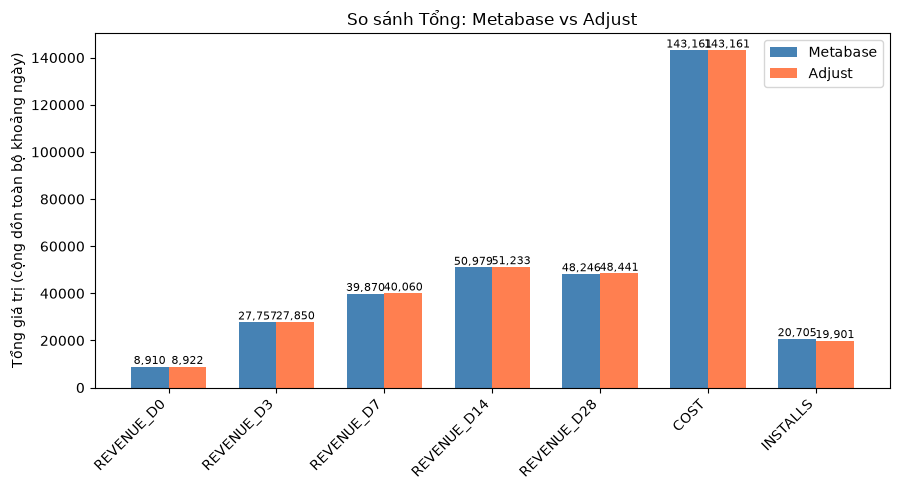

Đã lưu: D:\Document-D\2025.2\LabDATA\Game\QA\qa-pipeline\outputs\game_b_ios\reconciliation_totals_comparison.csv


In [83]:
from pathlib import Path

output_dir = Path("../outputs") / rc.GAME_KEY
output_dir.mkdir(parents=True, exist_ok=True)

totals = eda.compare_totals(detail)
eda.plot_totals_comparison(totals)

totals.to_csv(output_dir / "reconciliation_totals_comparison.csv", index=False, encoding="utf-8-sig")
print(f"Đã lưu: {(output_dir / 'reconciliation_totals_comparison.csv').resolve()}")

### 8.2. Tổng quan Campaign
Số lượng Campaign đang đối chiếu, và số ngày (cohort) mỗi Campaign có dữ liệu — giúp phát hiện
nhanh Campaign nào có mẫu quá nhỏ, cần cẩn trọng khi đọc % Discrepancy.

Số lượng Campaign đang đối chiếu: 2
                                n_days  first_date   last_date
campaign                                                      
CDS iOS - D28 AdROAS - 260212       45  2026-07-30  2026-09-12
CDS iOS - D28 BLDROAS - 260625      45  2026-07-30  2026-09-12


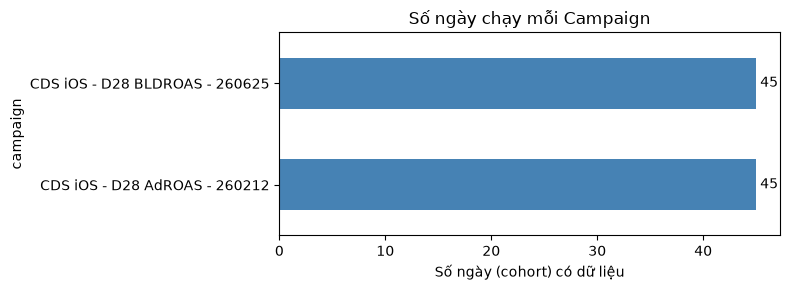

In [84]:
campaign_overview_df = eda.campaign_overview(detail)
eda.plot_campaign_overview(campaign_overview_df)

### 8.3. Heatmap % Discrepancy theo Campaign x Metric
Màu càng đỏ đậm, % Discrepancy càng cao — nhìn nhanh Campaign nào và Metric nào đang có vấn đề.

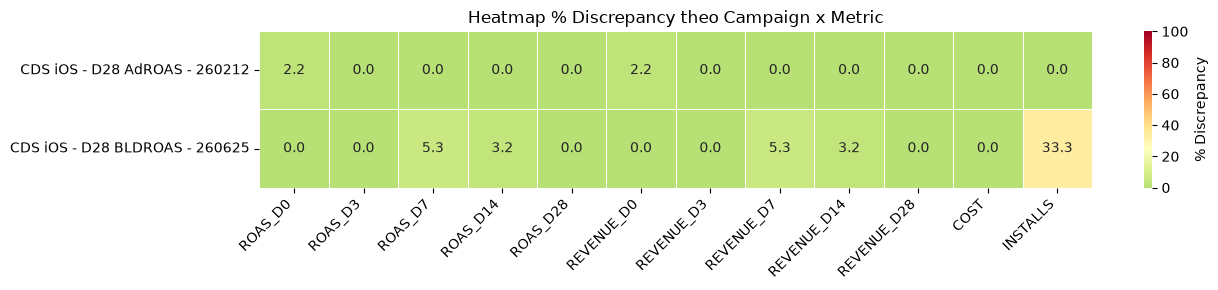

In [85]:
discrepancy_pivot = eda.plot_discrepancy_heatmap(summary_by_campaign)

### 8.4. Phân tích theo Metric — toàn hệ thống (gộp mọi Campaign)

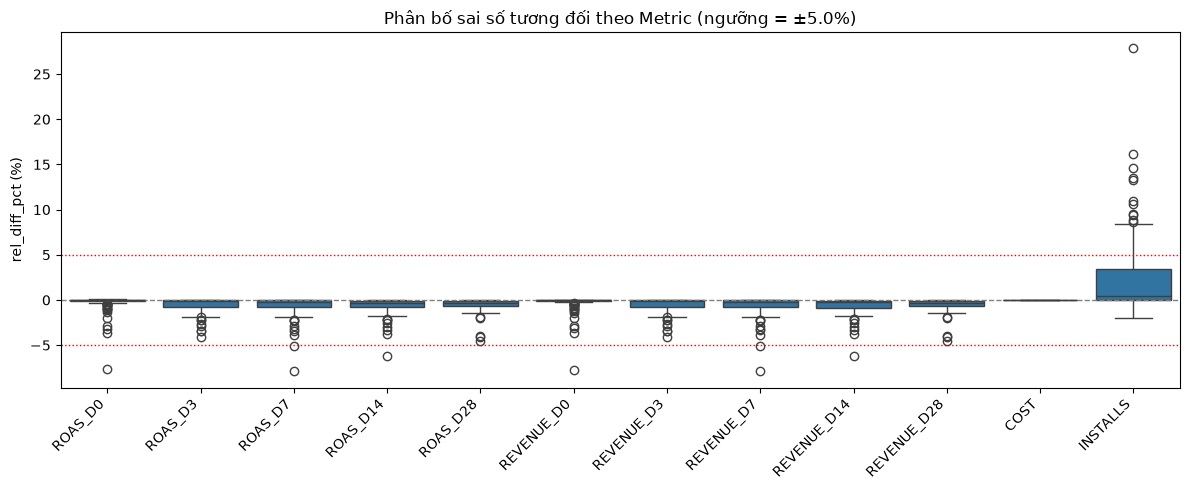

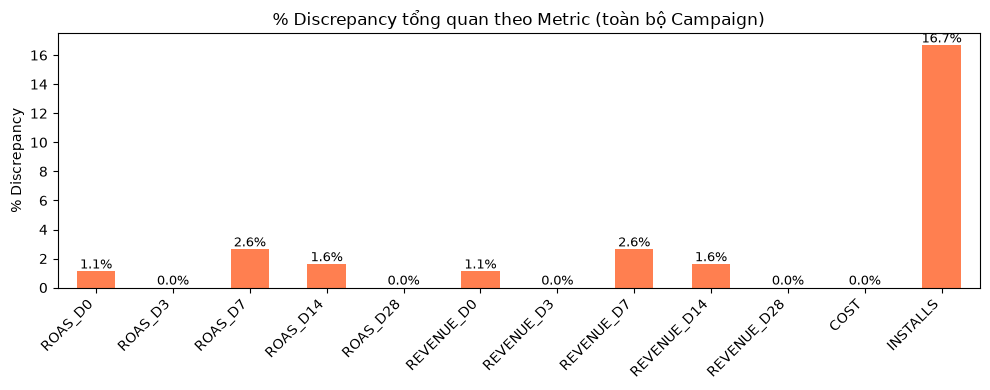

In [86]:
eda.plot_rel_diff_boxplot(detail)
eda.plot_overall_discrepancy_bar(summary_overall)

### 8.5. Xu hướng theo thời gian
- **Total**: trung bình `ratio = mb/adj` mỗi ngày, gộp tất cả campaign, cho vài metric đại diện.
- **Theo Campaign**: 1 đường/campaign, cho ĐÚNG 1 metric (đổi `metric=...` để xem chỉ số khác).

Đường `ratio = 1` (nét đứt) là khớp hoàn toàn.

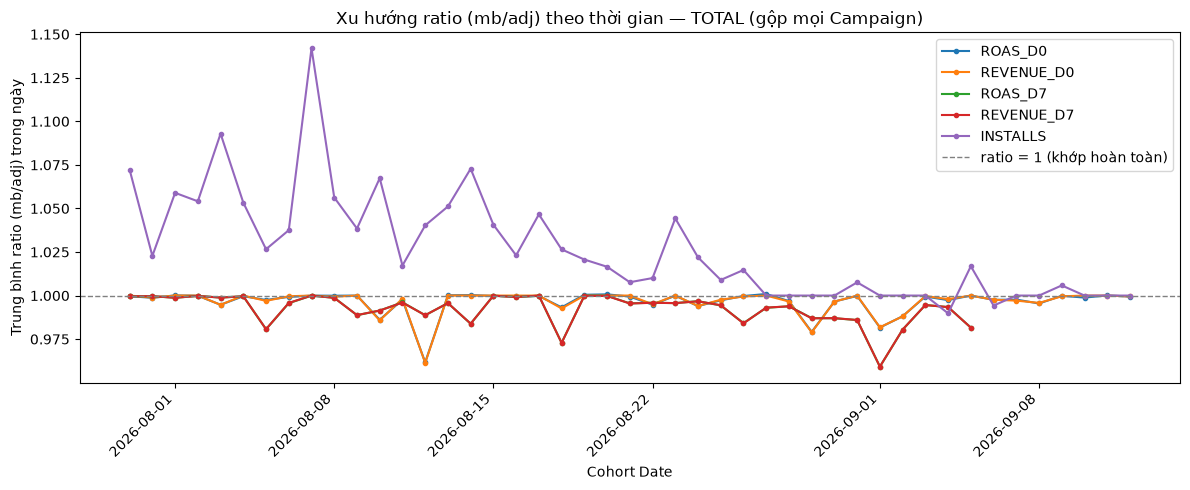

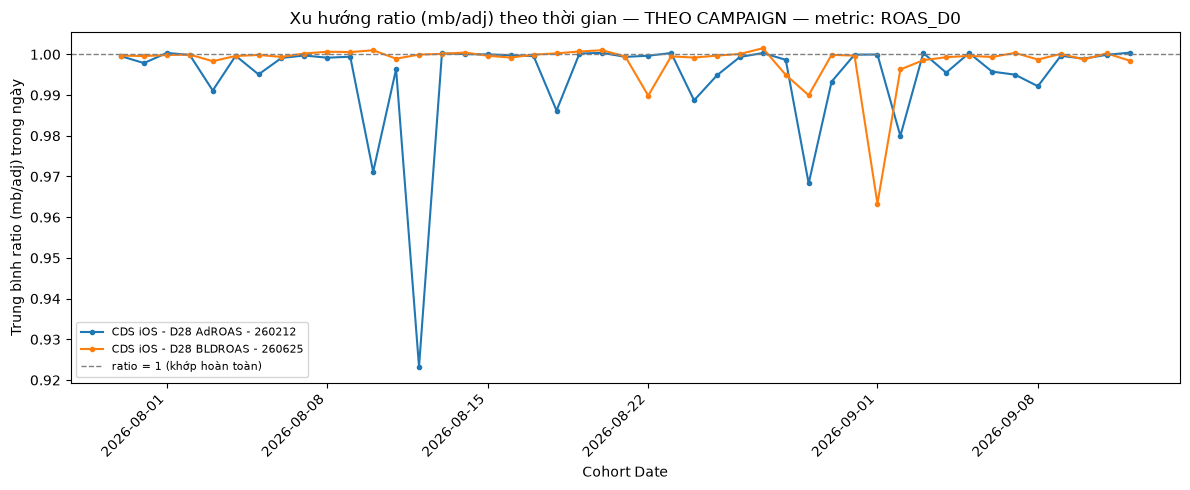

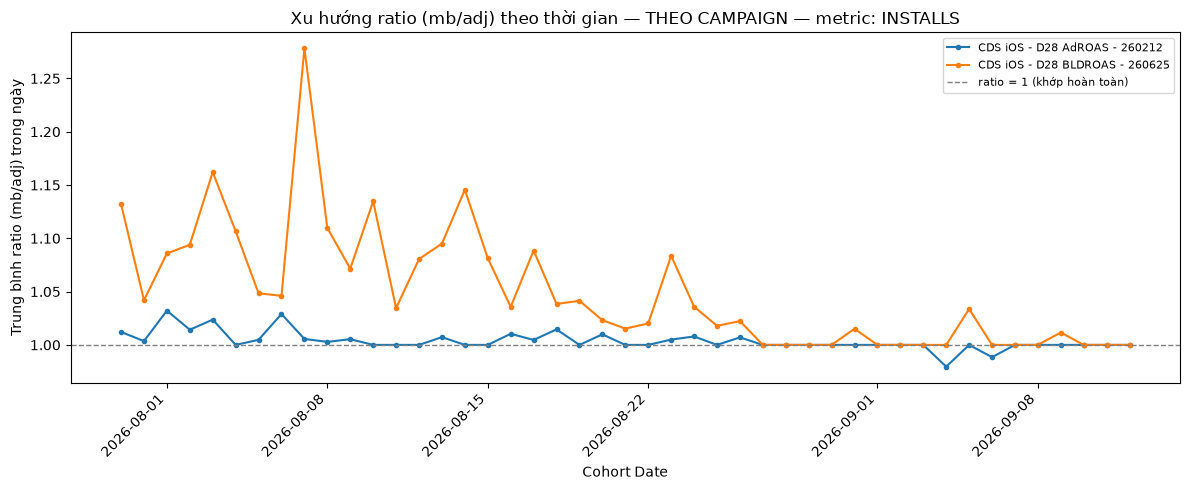

In [87]:
# Total — gộp mọi campaign
eda.plot_ratio_trend(detail, metrics=["ROAS_D0", "REVENUE_D0", "ROAS_D7", "REVENUE_D7", "INSTALLS"])

# Theo từng Campaign — đổi metric để xem chỉ số khác (VD "COST", "REVENUE_D7"...)
eda.plot_ratio_trend_by_campaign(detail, metric="ROAS_D0")
eda.plot_ratio_trend_by_campaign(detail, metric="INSTALLS")

### 8.7. Phân bố sai số tương đối — Histogram & ECDF
- **Histogram (tất cả Campaign)**: 1 ô/metric, thấy hình dạng phân bố thật (lệch, đa đỉnh...).
- **Histogram theo Campaign**: 1 ô/campaign, cho 1 metric cụ thể — phát hiện campaign nào
  gây lệch phân bố chung.
- **ECDF**: trả lời trực tiếp "bao nhiêu % cohort đạt ngưỡng ±5%?" — đọc tại giao điểm với
  đường ngưỡng đỏ.

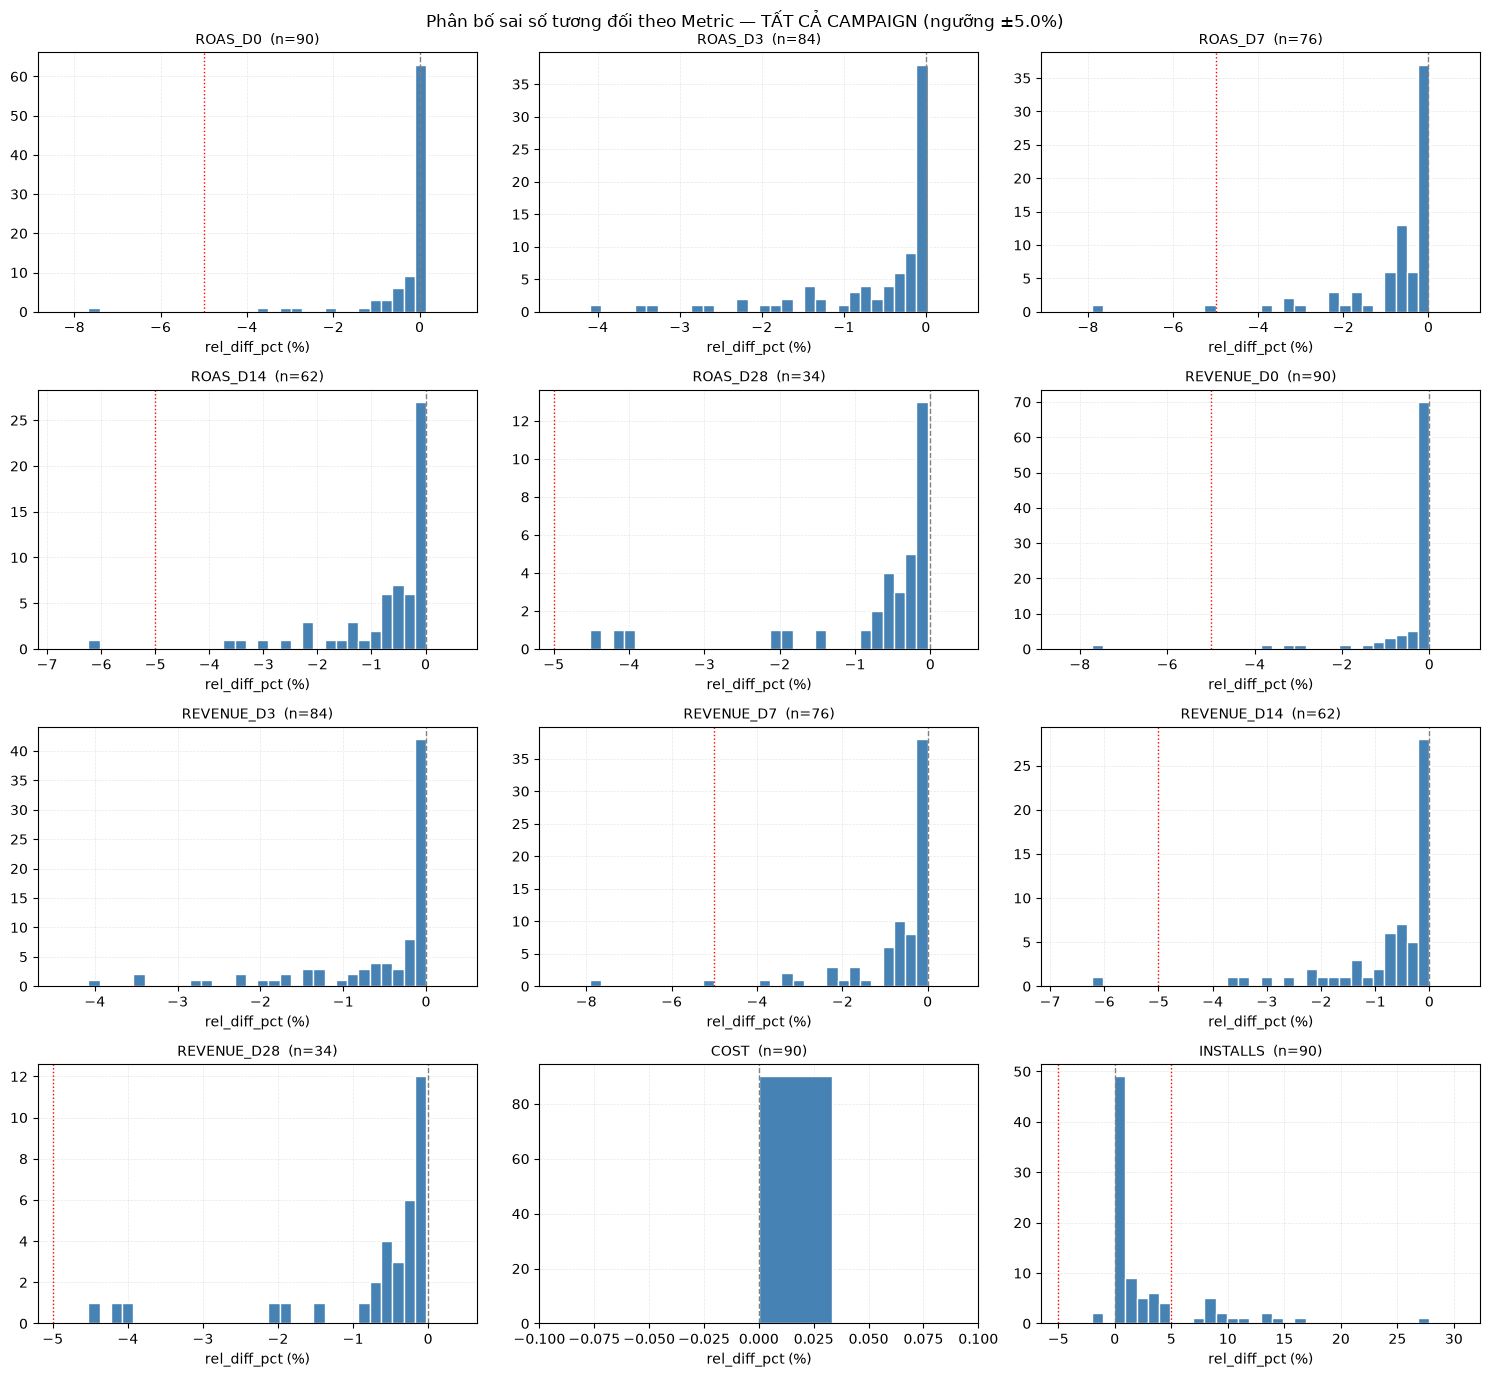

In [88]:
eda.plot_rel_diff_histogram(detail)

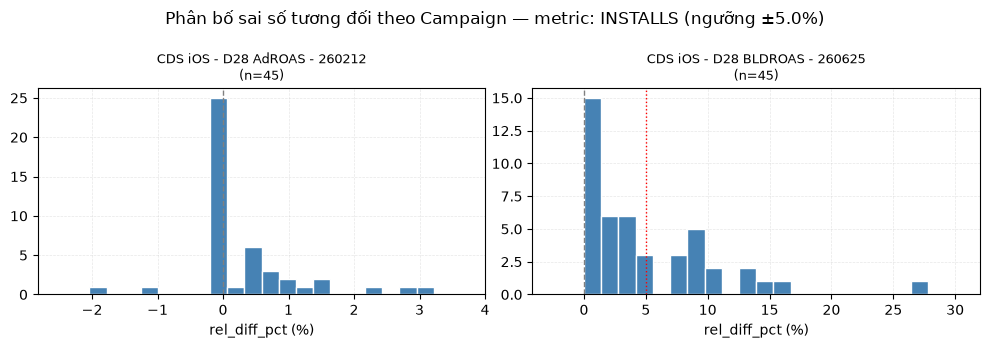

In [89]:
# Đổi metric để xem chỉ số khác (VD "COST", "REVENUE_D7"...)
eda.plot_rel_diff_histogram_by_campaign(detail, metric="INSTALLS")

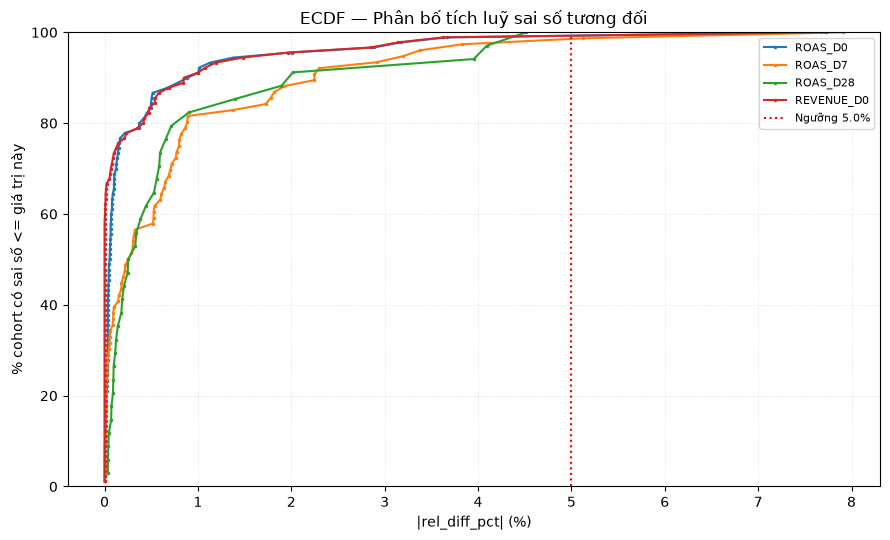

=== % cohort đạt ngưỡng (|rel_diff_pct| <= THRESHOLD_PCT) ===
    metric  n  pct_within_threshold
   ROAS_D0 90                  98.9
   ROAS_D7 76                  97.4
  ROAS_D28 34                 100.0
REVENUE_D0 90                  98.9


In [90]:
pct_within_df = eda.plot_rel_diff_ecdf(detail, metrics=["ROAS_D0", "ROAS_D7", "ROAS_D28", "REVENUE_D0"])